In [52]:
# Libraries
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier

# 1 Assessment of Data and Applying Normalization

## Wine

In [53]:
## Loading data set
wine_r = pd.read_csv('winequality-red.csv', sep=';')
wine_w = pd.read_csv('winequality-white.csv', sep=';')

In [54]:
print(wine_r.isnull().sum())
print(wine_w.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


Based on the red and white wine dataset, there appears to be no null values, so there isn't any missing data.

In [55]:
wine_w['color']= np.zeros(wine_w.shape[0])  ## white is 0
wine_r['color']= np.ones(wine_r.shape[0])  ## red is 1
wine = pd.concat([wine_w,wine_r])

In [56]:
summary = pd.DataFrame(index=wine.columns, columns=['mean', 'median', 'variance', 'skewness', 'kurtosis'])

for col in wine.columns:
    summary.loc[col, 'mean'] = wine[col].mean()
    summary.loc[col, 'median'] = wine[col].median()
    summary.loc[col, 'variance'] = wine[col].var()
    summary.loc[col, 'skewness'] = skew(wine[col])
    summary.loc[col, 'kurtosis'] = kurtosis(wine[col])

print("Summarization statistics for both wines")
print(summary)

Summarization statistics for both wines
                            mean   median     variance  skewness   kurtosis
fixed acidity           7.215307      7.0      1.68074  1.722892   5.056343
volatile acidity        0.339666     0.29     0.027105  1.494751   2.822275
citric acid             0.318633     0.31     0.021117  0.471622   2.394471
residual sugar          5.443235      3.0    22.636696  1.435073   4.354994
chlorides               0.056034    0.047     0.001227  5.398581  50.857966
free sulfur dioxide    30.525319     29.0   315.041192  1.219784   7.899231
total sulfur dioxide  115.744574    118.0  3194.720039 -0.001177  -0.372301
density                 0.994697  0.99489     0.000009  0.503485   6.600061
pH                      3.218501     3.21     0.025853  0.386749   0.366451
sulphates               0.531268     0.51     0.022143  1.796855   8.646117
alcohol                10.491801     10.3     1.422561  0.565587  -0.532202
quality                 5.818378      6.0     0.

Volatile acidity has a kurtosis value of 2.82, which is relatively close to 3, suggesting that it could follow a normal distribution.  
The chlorides level has a very high kurtosis value of 50.9 and skewness value of 5.4, which may imply that it has extreme outlier values mostly on the right side of the distribution.  
Total sulfur dioxide has a very high variance of 3195, which means it spans a wide range of values, but they are fairly distributed evenly on both sides as suggested by the low skewness and kurtosis values.  

c:\Users\peada\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


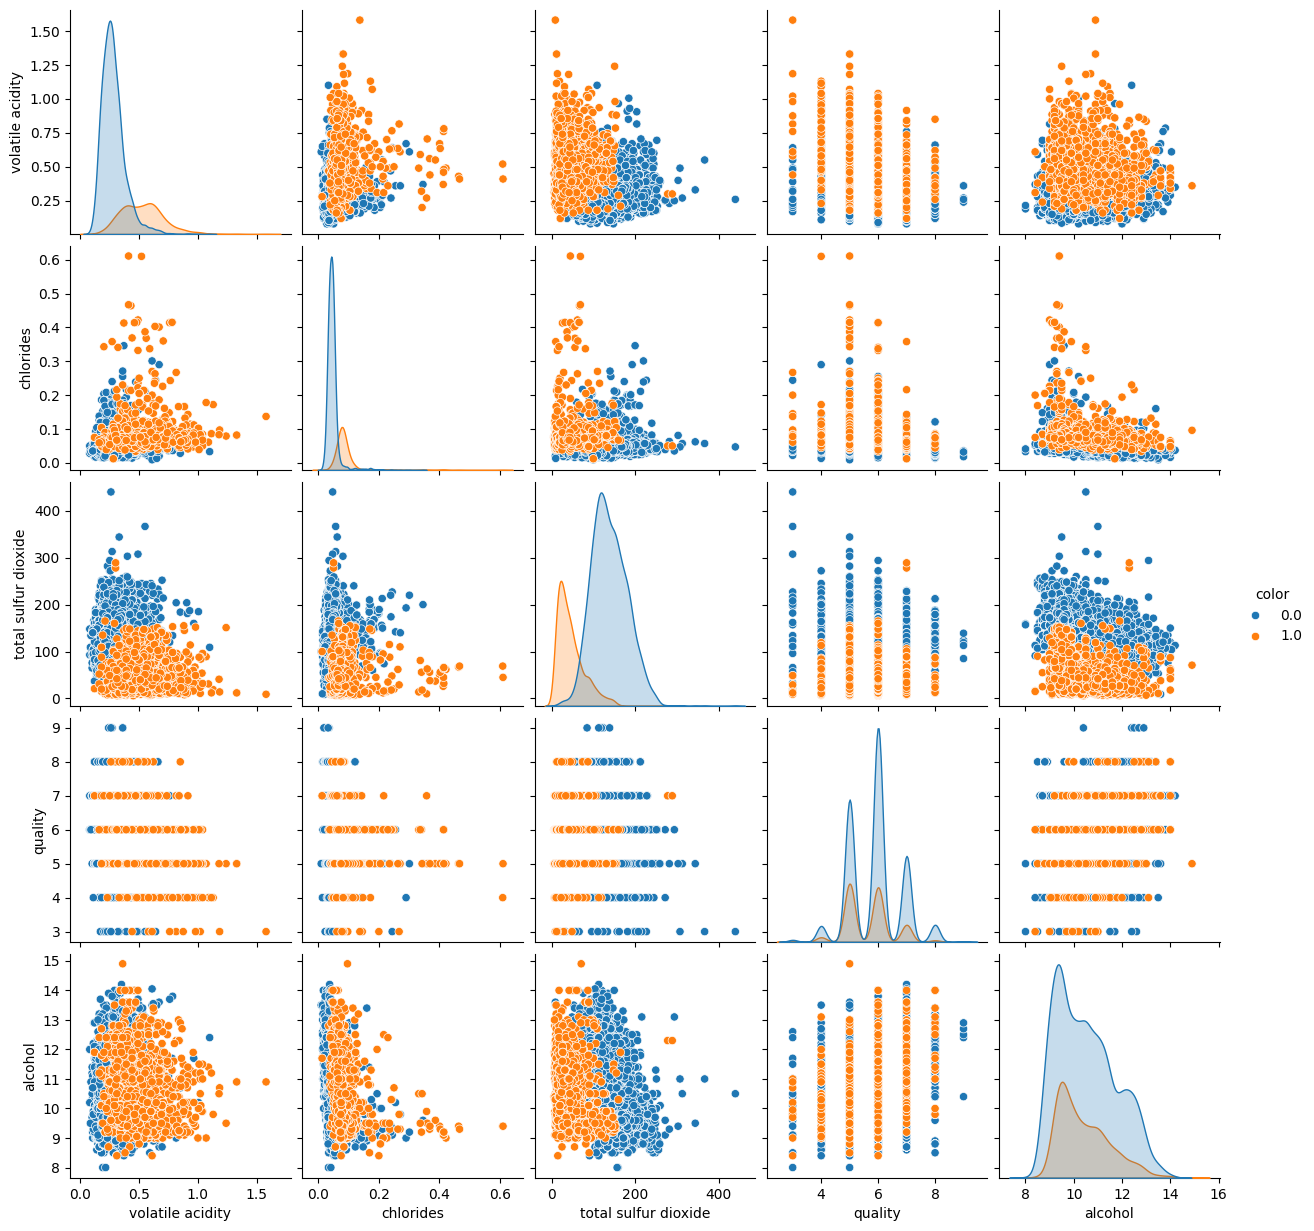

In [57]:
selected_features = ['volatile acidity', 'chlorides', 'total sulfur dioxide', 'quality', 'alcohol', 'color']
sns.pairplot(wine[selected_features], hue='color')
plt.show()

Although total sulfer dioxide has a very high variance, it seems that most of the data still correspond with low chloride levels of 0.2 and below. In the pairplot between alcohol and total sulfur dioxide, it appears that regardless of alcohol level between 8 to 14, the total sulfur dioxide level remains generally below 300.  
There seems to be a small correlation between quality and volatile acidity, where volatile acidity generally slightly falls as quality increases from 4 to 9.  
Red wine appears to generally have a lower total sulfur dioxide value compared to white wine, while having higher volatile acidity and chlorides.

In [58]:
class_counts = wine["color"].value_counts()
print("Class distribution:")
print(class_counts)

Class distribution:
color
0.0    4898
1.0    1599
Name: count, dtype: int64


This data set is balanced as there are sufficient representations (at least 1000) for both classes of wine, red and white.

In [59]:
features = wine.drop(columns=['color']).columns

## Z-score normalization
wine_normalised = wine.copy()
wine_normalised[features] = (wine[features] - wine[features].mean()) / wine[features].std()
wine_normalised

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,-0.166076,-0.423150,0.284664,3.206682,-0.314951,0.815503,0.959902,2.102052,-1.358944,-0.546136,-1.418449,0.207983,0.0
1,-0.706019,-0.240931,0.147035,-0.807775,-0.200775,-0.931035,0.287595,-0.232314,0.506876,-0.277330,-0.831551,0.207983,0.0
2,0.682405,-0.362411,0.559923,0.306184,-0.172231,-0.029596,-0.331634,0.134515,0.258100,-0.613338,-0.328496,0.207983,0.0
3,-0.011807,-0.666110,0.009405,0.642474,0.056121,0.928182,1.242978,0.301255,-0.177258,-0.882144,-0.496181,0.207983,0.0
4,-0.011807,-0.666110,0.009405,0.642474,0.056121,0.928182,1.242978,0.301255,-0.177258,-0.882144,-0.496181,0.207983,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,-0.783154,1.581266,-1.642146,-0.723703,0.969530,0.083083,-1.269324,0.067819,1.439786,0.327485,0.006874,-0.937157,1.0
1595,-1.014558,1.277566,-1.504517,-0.681666,0.170298,0.477463,-1.145479,0.141185,1.875144,1.537115,0.593772,0.207983,1.0
1596,-0.706019,1.034607,-1.298073,-0.660648,0.569914,-0.085936,-1.340094,0.347943,1.253204,1.469913,0.426087,0.207983,1.0
1597,-1.014558,1.854595,-1.366888,-0.723703,0.541370,0.083083,-1.269324,0.257903,2.186114,1.201107,-0.244653,-0.937157,1.0


## Abalone

In [60]:
## Loading data set
header = ['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight',  'Rings']
abalone = pd.read_csv('abalone.csv', names=header, header=None)
abalone

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [61]:
print(abalone.isnull().sum())

Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64


Based on the abalone dataset, there appears to be no null values, so there isn't any missing data.

In [62]:
numerical_features = abalone.select_dtypes(include=np.number).columns
summary = pd.DataFrame(index=numerical_features, columns=['mean', 'median', 'variance', 'skewness', 'kurtosis'])

for col in numerical_features:
    summary.loc[col, 'mean'] = abalone[col].mean()
    summary.loc[col, 'median'] = abalone[col].median()
    summary.loc[col, 'variance'] = abalone[col].var()
    summary.loc[col, 'skewness'] = skew(abalone[col])
    summary.loc[col, 'kurtosis'] = kurtosis(abalone[col])

print("Summarization statistics for abalones")
print(summary)

Summarization statistics for abalones
                    mean  median   variance  skewness   kurtosis
Length          0.523992   0.545   0.014422 -0.639643   0.063108
Diameter        0.407881   0.425   0.009849 -0.608979  -0.046857
Height          0.139516    0.14    0.00175  3.127694  75.933099
Whole weight    0.828742  0.7995   0.240481  0.530768  -0.025051
Shucked weight  0.359367   0.336   0.049268   0.71884   0.592975
Viscera weight  0.180594   0.171   0.012015   0.59164   0.082475
Shell weight    0.238831   0.234   0.019377  0.620704   0.529854
Rings           9.933684     9.0  10.395266  1.113702   2.326462


Height has a very high kurtosis of 75.9, which suggests that it is a distribution with a heavy tail, with more outliers than expected. The height is also concentrated closely near the mean, as seen from its low variance of 0.00175.  
Rings has a relatively high variance of 10.4, which could suggest that the rings could be fairly distributed, which is optimal since it is our target feature.  
The other features have a low kurtosis value near to 0, which indicates that they have a relatively normal distribution.

c:\Users\peada\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


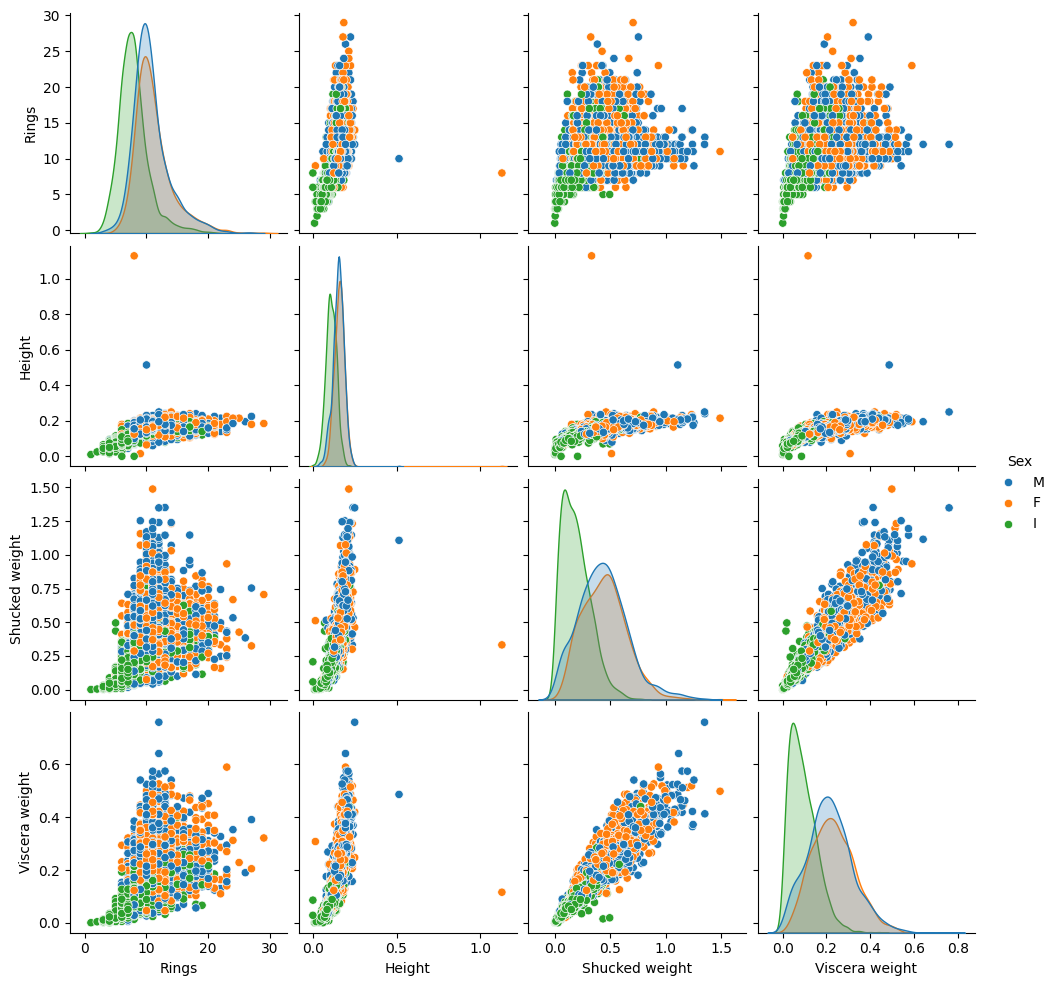

In [63]:
selected_features = ['Sex', 'Rings', 'Height', 'Shucked weight', 'Viscera weight']
sns.pairplot(abalone[selected_features], hue='Sex')
plt.show()

The heights of all abalones seem to generally be below 0.3, of which infants tend to lie below the 0.2 mark.  
There seems to be a correlation between height and rings as the rings increases when the height increases. In comparison, the other features like shucked weight and viscera weight seems to have a wider spread above 5 rings and show little correlation with the rings.  
Shucked weight also increases as viscera weight increases, suggesting a positive relationship, with infants populating majority of the data points at the lower end.

In [64]:
class_counts = abalone["Rings"].value_counts()
print("Class distribution:")
print(class_counts)

Class distribution:
Rings
9     689
10    634
8     568
11    487
7     391
12    267
6     259
13    203
14    126
5     115
15    103
16     67
17     58
4      57
18     42
19     32
20     26
3      15
21     14
23      9
22      6
27      2
24      2
1       1
26      1
29      1
2       1
25      1
Name: count, dtype: int64


I feel that this dataset is imbalanced because the rings have a skewed distribution, with most samples lying in the 8-12 rings range, and few in the extreme ends (<4 rings and >18 rings). This could result in the model predicting the 8-12 rings range accurately, while having unreliable predictions for extremely young and old abalones. We could remove data that has very little sample size for each ring value, for example 25 rings and 1 ring, where the sample size is only 1.

In [65]:
## Correction by removing classes with sample size less than 5
small_rings_sample = [27, 24, 1, 26, 29, 2, 25]

abalone = abalone[abalone['Rings'].apply(lambda x: x not in small_rings_sample)]

In [66]:
numerical_features = abalone.drop(columns=['Rings']).select_dtypes(include=['number']).columns  ## exclude 'Sex'
abalone_normalised = abalone.copy()

## Z-score normalization
abalone_normalised[numerical_features] = (abalone[numerical_features] - abalone[numerical_features].mean()) / abalone[numerical_features].std()
abalone_normalised

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,-0.576013,-0.432992,-1.066323,-0.641379,-0.607323,-0.725797,-0.638474,15
1,M,-1.452836,-1.443496,-1.186206,-1.231000,-1.170779,-1.205083,-1.216430,7
2,F,0.050288,0.122785,-0.107256,-0.308248,-0.463078,-0.356062,-0.205008,9
3,M,-0.701274,-0.432992,-0.347023,-0.637292,-0.647892,-0.607117,-0.602352,10
4,I,-1.619850,-1.544546,-1.425972,-1.272897,-1.215855,-1.287247,-1.324797,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.342563,0.425937,0.612043,0.120939,0.048539,0.534041,0.076746,11
4173,M,0.551330,0.324886,-0.107256,0.282395,0.359567,0.310374,0.159827,10
4174,M,0.634837,0.678563,1.571109,0.711582,0.749478,0.976810,0.502988,9
4175,F,0.843604,0.779613,0.252393,0.545016,0.774270,0.734885,0.416295,10


# 2 Classification with KNN

## Wine

In [67]:
## Classify color of wine with all features
X = wine_normalised.drop(columns=['color'])  ## Features
y = wine_normalised['color']  ## Target

## 80%-20% training, test split
wine_X_train, wine_X_test, wine_y_train, wine_y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, stratify=y)

In [68]:
## KNN with 5-fold cross validation to find best k parameter
k_values = range(1, 30)
accuracy_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    current_scores = cross_val_score(knn, wine_X_train, wine_y_train, cv=5, scoring='accuracy')  ## 5 fold cross validation
    accuracy_scores.append(current_scores.mean())

## Best k parameter
best_wine_k_knn = k_values[np.argmax(accuracy_scores)]
print('Best k parameter:', best_wine_k_knn)

Best k parameter: 4


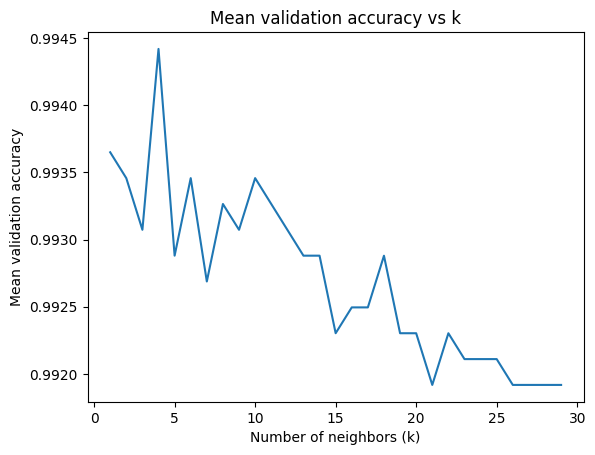

In [69]:
plt.plot(k_values, accuracy_scores,)
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Mean validation accuracy')
plt.title('Mean validation accuracy vs k')
plt.show()

### Using the best k parameter to retrain the KNN

In [70]:
## Retraining KNN
best_knn = KNeighborsClassifier(n_neighbors=best_wine_k_knn)
best_knn.fit(wine_X_train, wine_y_train)

## Calculate accuracy on Test set
best_y_pred = best_knn.predict(wine_X_test)
test_accuracy = accuracy_score(wine_y_test, best_y_pred)

print(f'Test accuracy with best k value of {best_wine_k_knn}: {test_accuracy}')

Test accuracy with best k value of 4: 0.9923076923076923


### Using distance to train a weighted KNN

In [71]:
## Retraining weighted KNN
knn_weighted = KNeighborsClassifier(n_neighbors=best_wine_k_knn, weights='distance')
knn_weighted.fit(wine_X_train, wine_y_train)

## Calculate accuracy on Test set
weighted_y_pred = knn_weighted.predict(wine_X_test)
weighted_test_accuracy = accuracy_score(wine_y_test, weighted_y_pred)

print(f'Test accuracy for weighted KNN based on distance with best k value of {best_wine_k_knn}: {weighted_test_accuracy}')

Test accuracy for weighted KNN based on distance with best k value of 4: 0.9923076923076923


In [72]:
if (test_accuracy > weighted_test_accuracy):
	best_knn_wine_acc = test_accuracy
	wine_weighted = False
else:
	best_knn_wine_acc = weighted_test_accuracy
	wine_weighted = 'distance'
print(f'Best KNN accuracy for wine data set: {best_knn_wine_acc}')

Best KNN accuracy for wine data set: 0.9923076923076923


## Abalone

In [73]:
sex_map = {'M': 0, 'F': 1, 'I': 2}
abalone_normalised['Sex'] = abalone_normalised['Sex'].map(sex_map)

In [74]:
## Classify rings of abalone with all features
X = abalone_normalised.drop(columns=['Rings'])  ## Features
y = abalone_normalised['Rings']  ## Target

## 80%-20% training, test split
abalone_X_train, abalone_X_test, abalone_y_train, abalone_y_test = train_test_split(X, y, test_size=0.2, train_size=0.8)

In [75]:
## KNN with 5-fold cross validation to find best k parameter
k_values = range(1, 50)
accuracy_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    current_scores = cross_val_score(knn, abalone_X_train, abalone_y_train, cv=5, scoring='accuracy')  ## 5 fold cross validation
    accuracy_scores.append(current_scores.mean())

## Best k parameter
best_abalone_k_knn = k_values[np.argmax(accuracy_scores)]
print('Best k parameter:', best_abalone_k_knn)

c:\Users\peada\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\peada\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\peada\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\peada\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\peada\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.

Best k parameter: 33


c:\Users\peada\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


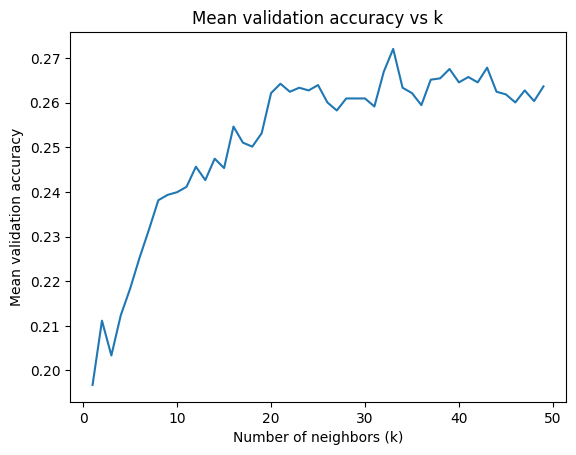

In [76]:
plt.plot(k_values, accuracy_scores,)
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Mean validation accuracy')
plt.title('Mean validation accuracy vs k')
plt.show()

### Using the best k parameter to retrain the KNN

In [77]:
## Retraining KNN
best_knn = KNeighborsClassifier(n_neighbors=best_abalone_k_knn)
best_knn.fit(abalone_X_train, abalone_y_train)

## Calculate accuracy on Test set
best_y_pred = best_knn.predict(abalone_X_test)
test_accuracy = accuracy_score(abalone_y_test, best_y_pred)

print(f'Test accuracy with best k value of {best_abalone_k_knn}: {test_accuracy}')

Test accuracy with best k value of 33: 0.24100719424460432


Using distance to train weighted KNN

In [78]:
## Retraining weighted KNN
knn_weighted = KNeighborsClassifier(n_neighbors=best_abalone_k_knn, weights='distance')
knn_weighted.fit(abalone_X_train, abalone_y_train)

## Calculate accuracy on Test set
weighted_y_pred = knn_weighted.predict(abalone_X_test)
weighted_test_accuracy = accuracy_score(abalone_y_test, weighted_y_pred)

print(f'Test accuracy for weighted KNN based on distance with best k value of {best_abalone_k_knn}: {weighted_test_accuracy}')

Test accuracy for weighted KNN based on distance with best k value of 33: 0.24580335731414868


In [79]:
if (test_accuracy > weighted_test_accuracy):
	best_knn_abalone_acc = test_accuracy
	weighted_abalone = False
else:
	best_knn_abalone_acc = weighted_test_accuracy
	weighted_abalone = 'distance'
print(f'Best KNN accuracy for abalone data set: {best_knn_abalone_acc}')

Best KNN accuracy for abalone data set: 0.24580335731414868


# 3 Decision Trees Classifer

## Wine

In [80]:
decision_tree = DecisionTreeClassifier()
param_grid = {'max_depth': range(1, 30)}

grid_search = GridSearchCV(decision_tree, param_grid, cv=5, scoring='accuracy')
grid_search.fit(wine_X_train, wine_y_train)

## Best max_depth parameter
best_wine_depth_decisiontree = grid_search.best_params_['max_depth']
best_accuracy = grid_search.best_score_
print(f'Best tree depth parameter: {best_wine_depth_decisiontree}')
print(f'Best accuracy with tree depth of {best_wine_depth_decisiontree}: {best_accuracy}')

Best tree depth parameter: 9
Best accuracy with tree depth of 9: 0.9869154882653438


### Plotting mean accuracy vs tree depth

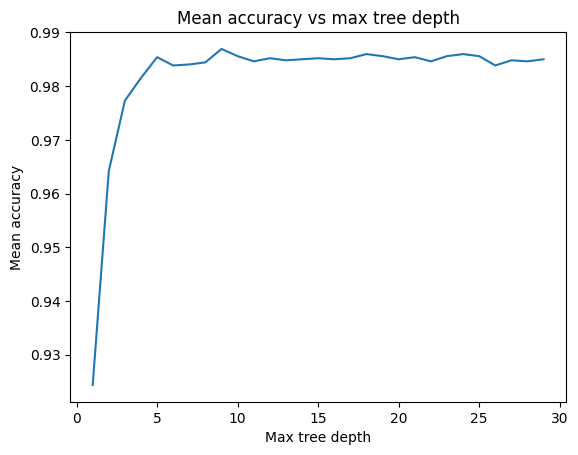

In [81]:
max_depths = range(1, 30)
mean_accuracies = grid_search.cv_results_['mean_test_score']

plt.plot(max_depths, mean_accuracies)
plt.xlabel('Max tree depth')
plt.ylabel('Mean accuracy')
plt.title('Mean accuracy vs max tree depth')
plt.show()

### Using best max_depth parameter to retrain decision tree

In [82]:
wine_final_tree = DecisionTreeClassifier(max_depth=best_wine_depth_decisiontree)
wine_final_tree.fit(wine_X_train, wine_y_train)

wine_y_pred = wine_final_tree.predict(wine_X_test)
wine_test_decision_accuracy = accuracy_score(wine_y_test, wine_y_pred)

print(f'Test accuracy with best tree depth of {best_wine_depth_decisiontree}: {wine_test_decision_accuracy}')

Test accuracy with best tree depth of 9: 0.9830769230769231


### Interpretability of decision tree

In [83]:
tree_rules = export_text(wine_final_tree, feature_names=list(wine_X_train.columns))
print(tree_rules)

|--- chlorides <= 0.13
|   |--- total sulfur dioxide <= -1.15
|   |   |--- chlorides <= -0.53
|   |   |   |--- pH <= 2.53
|   |   |   |   |--- class: 0.0
|   |   |   |--- pH >  2.53
|   |   |   |   |--- class: 1.0
|   |   |--- chlorides >  -0.53
|   |   |   |--- sulphates <= -0.81
|   |   |   |   |--- chlorides <= -0.06
|   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- chlorides >  -0.06
|   |   |   |   |   |--- class: 1.0
|   |   |   |--- sulphates >  -0.81
|   |   |   |   |--- density <= -1.10
|   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- density >  -1.10
|   |   |   |   |   |--- density <= -0.74
|   |   |   |   |   |   |--- pH <= 0.94
|   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |--- pH >  0.94
|   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |--- density >  -0.74
|   |   |   |   |   |   |--- class: 1.0
|   |--- total sulfur dioxide >  -1.15
|   |   |--- pH <= 1.97
|   |   |   |--- sulphates <= 5.50
|   |   |   |   |--- chlorid

Based on the decision tree, it is seen that total sulfur dioxide is the first split, which strongly suggests that it is important in differentiating between red and white wines. This is also observed from the pairsplot, where red wine tend to have lesser total sulfur dioxide than white wine.  
The same also applies to chlorides as it appears as the second split for both subtrees after the first split.   
Sulfates and the volatile acidity also seem to play a role in differentiating between the wine color.

## Abalone

In [84]:
decision_tree = DecisionTreeClassifier()
param_grid = {'max_depth': range(1, 30)}

grid_search = GridSearchCV(decision_tree, param_grid, cv=5, scoring='accuracy')
grid_search.fit(abalone_X_train, abalone_y_train)

## Best max_depth parameter
best_abalone_depth_decisiontree = grid_search.best_params_['max_depth']
best_accuracy = grid_search.best_score_
print(f'Best tree depth parameter: {best_abalone_depth_decisiontree}')
print(f'Best accuracy with tree depth of {best_abalone_depth_decisiontree}: {best_accuracy}')

c:\Users\peada\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Best tree depth parameter: 5
Best accuracy with tree depth of 5: 0.26335120727924327


### Plotting mean accuracy vs tree depth

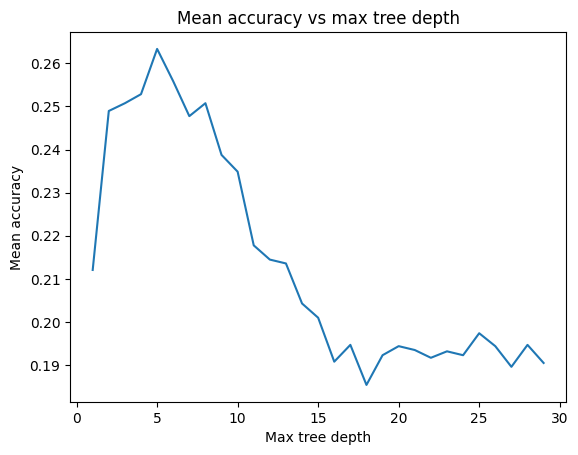

In [85]:
max_depths = range(1, 30)
mean_accuracies = grid_search.cv_results_['mean_test_score']

plt.plot(max_depths, mean_accuracies)
plt.xlabel('Max tree depth')
plt.ylabel('Mean accuracy')
plt.title('Mean accuracy vs max tree depth')
plt.show()

### Using best max_depth parameter to retrain decision tree

In [86]:
abalone_final_tree = DecisionTreeClassifier(max_depth=best_abalone_depth_decisiontree)
abalone_final_tree.fit(abalone_X_train, abalone_y_train)

abalone_y_pred = abalone_final_tree.predict(abalone_X_test)
abalone_test_decision_accuracy = accuracy_score(abalone_y_test, abalone_y_pred)

print(f'Test accuracy with best tree depth of {best_abalone_depth_decisiontree}: {abalone_test_decision_accuracy}')

Test accuracy with best tree depth of 5: 0.2637889688249401


### Interpretability of decision tree

In [87]:
tree_rules = export_text(abalone_final_tree, feature_names=list(abalone_X_train.columns))
print(tree_rules)

|--- Shell weight <= -0.69
|   |--- Diameter <= -1.87
|   |   |--- Viscera weight <= -1.55
|   |   |   |--- Whole weight <= -1.60
|   |   |   |   |--- Shucked weight <= -1.55
|   |   |   |   |   |--- class: 4
|   |   |   |   |--- Shucked weight >  -1.55
|   |   |   |   |   |--- class: 3
|   |   |   |--- Whole weight >  -1.60
|   |   |   |   |--- class: 4
|   |   |--- Viscera weight >  -1.55
|   |   |   |--- Viscera weight <= -1.41
|   |   |   |   |--- Whole weight <= -1.49
|   |   |   |   |   |--- class: 5
|   |   |   |   |--- Whole weight >  -1.49
|   |   |   |   |   |--- class: 5
|   |   |   |--- Viscera weight >  -1.41
|   |   |   |   |--- Viscera weight <= -1.31
|   |   |   |   |   |--- class: 6
|   |   |   |   |--- Viscera weight >  -1.31
|   |   |   |   |   |--- class: 5
|   |--- Diameter >  -1.87
|   |   |--- Sex <= 1.50
|   |   |   |--- Shucked weight <= -0.57
|   |   |   |   |--- Shell weight <= -1.32
|   |   |   |   |   |--- class: 7
|   |   |   |   |--- Shell weight >  -1.32

Since the first split is shell weight, it suggests that shell weight plays an important role in determining the number of rings of an abalone.  
Other factors that plays a role includes sex, diameter, shell weight and length. 

# 4 Random Forest Classifier

## Wine

In [88]:
random_forest = RandomForestClassifier()
param_grid = {'n_estimators': range(1, 30), 'max_depth': range(1, 30)}

grid_search = GridSearchCV(random_forest, param_grid, cv=5, scoring='root_mean_squared_error')
grid_search.fit(wine_X_train, wine_y_train)

results = pd.DataFrame(grid_search.cv_results_)

c:\Users\peada\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


### Plotting the heatmap with mean test score as the values

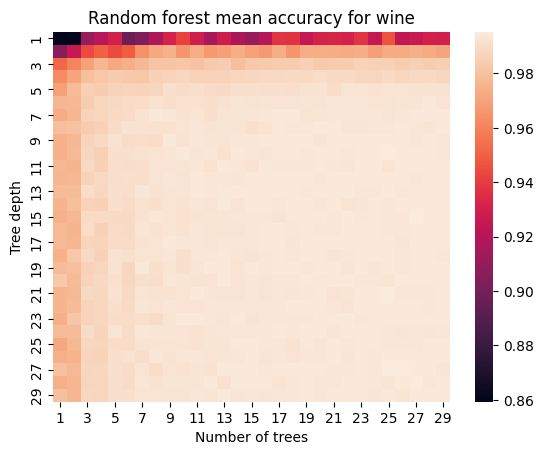

Best tree depth: 15
Best number of trees: 27
Best accuracy: 0.9951899015325388


In [89]:
heat_map_data = results.pivot(index='param_max_depth', columns='param_n_estimators', values='mean_test_score')

sns.heatmap(heat_map_data)
plt.title('Random forest mean accuracy for wine')
plt.xlabel('Number of trees')
plt.ylabel('Tree depth')
plt.show()

## Best parameters
best_wine_depth_forest = grid_search.best_params_['max_depth']
best_wine_n_estimators_forest = grid_search.best_params_['n_estimators']
best_accuracy = grid_search.best_score_
print('Best tree depth:', best_wine_depth_forest)
print('Best number of trees:', best_wine_n_estimators_forest)
print('Best accuracy:', best_accuracy)

### Using best parameters to retrain random forest and predict test values

In [90]:
wine_final_forest = RandomForestClassifier(max_depth=best_wine_depth_forest, n_estimators=best_wine_n_estimators_forest)
wine_final_forest.fit(wine_X_train, wine_y_train)

wine_y_pred = wine_final_forest.predict(wine_X_test)
wine_test_forest_accuracy = accuracy_score(wine_y_test, wine_y_pred)

print(f'Test accuracy with best tree depth of {best_wine_depth_forest} and best number of trees of {best_wine_n_estimators_forest}: {wine_test_forest_accuracy}')

Test accuracy with best tree depth of 15 and best number of trees of 27: 0.9946153846153846


## Abalone

In [91]:
random_forest = RandomForestClassifier()
param_grid = {'n_estimators': range(1, 30), 'max_depth': range(1, 30)}

grid_search = GridSearchCV(random_forest, param_grid, cv=5, scoring='accuracy')
grid_search.fit(abalone_X_train, abalone_y_train)

results = pd.DataFrame(grid_search.cv_results_)

c:\Users\peada\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


### Plotting heatmap with mean test scores as values

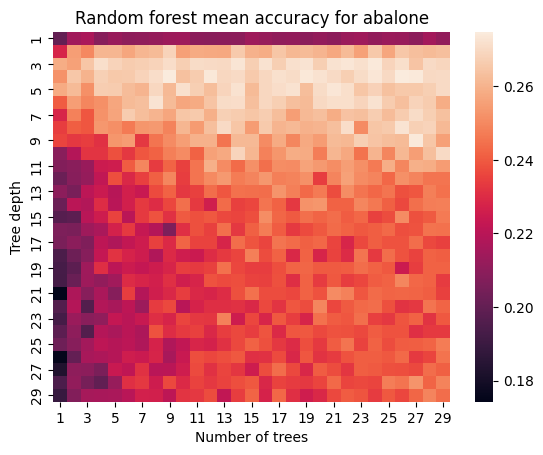

Best tree depth: 4
Best number of trees: 9
Best accuracy: 0.27475181328254794


In [92]:
heat_map_data = results.pivot(index='param_max_depth', columns='param_n_estimators', values='mean_test_score')

sns.heatmap(heat_map_data)
plt.title('Random forest mean accuracy for abalone')
plt.xlabel('Number of trees')
plt.ylabel('Tree depth')
plt.show()

## Best parameters
best_abalone_depth_forest = grid_search.best_params_['max_depth']
best_abalone_n_estimators_forest = grid_search.best_params_['n_estimators']
best_accuracy = grid_search.best_score_
print('Best tree depth:', best_abalone_depth_forest)
print('Best number of trees:', best_abalone_n_estimators_forest)
print('Best accuracy:', best_accuracy)

### Using best parameters to retrain random forest and predict test values

In [93]:
abalone_final_forest = RandomForestClassifier(max_depth=best_abalone_depth_forest, n_estimators=best_abalone_n_estimators_forest)
abalone_final_forest.fit(abalone_X_train, abalone_y_train)

abalone_y_pred = abalone_final_forest.predict(abalone_X_test)
abalone_test_forest_accuracy = accuracy_score(abalone_y_test, abalone_y_pred)

print(f'Test accuracy with best tree depth of {best_abalone_depth_forest} and best number of trees of {best_abalone_n_estimators_forest}: {abalone_test_forest_accuracy}')

Test accuracy with best tree depth of 4 and best number of trees of 9: 0.2589928057553957


# 5 Final Results

In [94]:
final_results = {
	'': ['KNN', 'Decision Tree', 'Random Forest'],
	'best settings (wine)': [f'k = {best_wine_k_knn}, weighted = {wine_weighted}', f'max depth = {best_wine_depth_decisiontree}', f'max depth = {best_wine_depth_forest}, number of trees = {best_wine_n_estimators_forest}'],
	'best settings (abalone)': [f'k = {best_abalone_k_knn}, weighted = {weighted_abalone}', f'max depth = {best_abalone_depth_decisiontree}', f'max depth = {best_abalone_depth_forest}, number of trees = {best_abalone_n_estimators_forest}'],
	'wine': [best_knn_wine_acc, wine_test_decision_accuracy, wine_test_forest_accuracy],
	'abalone': [best_knn_abalone_acc, abalone_test_decision_accuracy, abalone_test_forest_accuracy]
}

final_results_df = pd.DataFrame(final_results)
print(final_results_df.to_string(index=False))

                              best settings (wine)            best settings (abalone)     wine  abalone
          KNN           k = 4, weighted = distance        k = 33, weighted = distance 0.992308 0.245803
Decision Tree                        max depth = 9                      max depth = 5 0.983077 0.263789
Random Forest max depth = 15, number of trees = 27 max depth = 4, number of trees = 9 0.994615 0.258993


Overall, the KNN seemed to performed slightly worse in comparison to decision tree and random forest. The decision tree with max depth 5 seemed to work best for the abalone dataset, while random forest with max depth of 15 and 27 trees seemed to work best for the wine dataset.